# **ML Assignment 01 – Sahil’s Wildlife Rescue Classification Challenge**

Sahil runs a small wildlife rescue centre. Whenever an injured bird is brought in, the staff record details about it like species, weight, habitat, injury type, etc. He now wants to build a simple Machine Learning model that predicts whether a rescued bird will recover or not within two weeks.

You have been hired as a Data Science Assistant at Sahil’s Wildlife Care to help automate this process using the techniques you learned in class.

**Dataset:** sahil_wildlife_recovery.csv

The dataset contains 1,000 records, each representing a rescued bird.
Each row includes various features related to the bird’s condition and background.

| Column Name          | Description                                                                             |
| -------------------- | --------------------------------------------------------------------------------------- |
| `bird_id`            | Unique ID for each bird                                                                 |
| `species`            | Type of bird (e.g., Sparrow, Parrot, Falcon, Crow, Pigeon)                              |
| `age_group`          | Age group (Chick, Juvenile, Adult)                                                      |
| `weight`             | Weight in grams                                                                         |
| `injury_type`        | Main injury (Wing Fracture, Leg Injury, Dehydration, Poisoning, Minor Cut, Head Trauma) |
| `habitat_region`     | Area bird was rescued from (Urban, Forest, Desert, Coastal)                             |
| `arrival_day`        | Day of the week it arrived                                                              |
| `received_treatment` | Whether treatment was administered on the first day (Yes/No)                            |
| `hours_in_care`      | Total hours spent under care so far                                                     |
| `recovered`          | **Target variable** — whether the bird recovered within 14 days (Yes/No)                |

You will use classification algorithms to predict `recovered`.

## **Step 1 – Exploring the Dataset (10 marks)**

Load the dataset and display the first 10 rows to get an overview (2 marks)

In [103]:

import pandas as pd

file_path="/content/sahil_wildlife_recovery - sahil_wildlife_recovery.csv"
df=pd.read_csv(file_path)
df.head(10)    #by default this fucntion prints the first 5 rows

,bird_id,species,age_group,weight,injury_type,habitat_region,arrival_day,received_treatment,hours_in_care,recovered
0,B001,Sparrow,Adult,45,Minor Cut,Urban,Monday,Yes,72,Yes
1,B002,Parrot,Juvenile,95,Wing Fracture,Forest,Tuesday,Yes,168,Yes
2,B003,Crow,Adult,120,Dehydration,Urban,Wednesday,No,24,No
3,B004,Falcon,Adult,980,Leg Injury,Desert,Thursday,Yes,210,Yes
4,B005,Pigeon,Juvenile,320,Minor Cut,Urban,Friday,Yes,60,Yes
5,B006,Sparrow,Chick,30,Poisoning,Urban,Saturday,No,36,No
6,B007,Parrot,Adult,105,Head Trauma,Forest,Sunday,Yes,192,No
7,B008,Crow,Juvenile,150,Dehydration,Coastal,Monday,Yes,84,Yes
8,B009,Falcon,Adult,1100,Leg Injury,Desert,Tuesday,Yes,240,Yes
9,B010,Pigeon,Chick,280,Wing Fracture,Urban,Wednesday,No,48,No


In [104]:
df['age_group'].unique()

array(['Adult', 'Juvenile', 'Chick'], dtype=object)

Check basic information and shape of the dataset (2 marks)

In [105]:
df.shape

(1000, 10)

In [106]:
df.info()   # all the data types are also correct

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   bird_id             1000 non-null   object
 1   species             1000 non-null   object
 2   age_group           1000 non-null   object
 3   weight              1000 non-null   int64 
 4   injury_type         1000 non-null   object
 5   habitat_region      1000 non-null   object
 6   arrival_day         1000 non-null   object
 7   received_treatment  1000 non-null   object
 8   hours_in_care       1000 non-null   int64 
 9   recovered           1000 non-null   object
dtypes: int64(2), object(8)
memory usage: 78.3+ KB


In [107]:
df.describe()  #this shows that we have only 2 numeric columns

,weight,hours_in_care
count,1000.000000,1000.000000
mean,308.257000,131.470000
std,344.652344,53.795251
min,28.000000,18.000000
25%,74.000000,96.000000
50%,130.000000,132.000000
75%,315.000000,168.000000
max,1100.000000,240.000000


In [108]:
df.describe(include="object")  #we have 8 categorical columns

,bird_id,species,age_group,injury_type,habitat_region,arrival_day,received_treatment,recovered
count,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,5,3,6,4,7,2,2
top,B1000,Sparrow,Adult,Poisoning,Urban,Monday,Yes,Yes
freq,1,200,578,198,401,143,870,868


Check for missing values and duplicates in the dataset (3 marks)

In [109]:
df.isnull().sum()

,0
bird_id,0
species,0
age_group,0
weight,0
injury_type,0
habitat_region,0
arrival_day,0
received_treatment,0
hours_in_care,0
recovered,0


In [110]:
df.duplicated().sum()

np.int64(0)

In [111]:
#as bird_id is a unique variable we can see if there are any duplicates there

df['bird_id'].duplicated().sum()

np.int64(0)

Show the unique values in the target column `recovered` and count how many birds recovered and how many did not (3 marks)

In [112]:
df["recovered"].unique()

array(['Yes', 'No'], dtype=object)

In [113]:
df[df['recovered'] == 'Yes'].count()   #868 were recovered

,0
bird_id,868
species,868
age_group,868
weight,868
injury_type,868
habitat_region,868
arrival_day,868
received_treatment,868
hours_in_care,868
recovered,868


In [114]:
df[df['recovered'] == 'No'].count()  #132 were not recovered

,0
bird_id,132
species,132
age_group,132
weight,132
injury_type,132
habitat_region,132
arrival_day,132
received_treatment,132
hours_in_care,132
recovered,132


## **Step 2 – Data Cleaning & Preprocessing (15 marks)**

Handle missing values if any, and remove duplicates if found (3 marks)

In [115]:
#there are no missing values and no duplicates were found in the data set


Encode the categorical columns using One-Hot Encoding (4 marks) and Scale numeric columns using StandardScaler (4 marks)

In [116]:
import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [117]:
# Define the lists of features
numeric_features = ["weight", "hours_in_care"]
nominal_features = ["bird_id", "species", "injury_type", "habitat_region", "arrival_day", "received_treatment"]
ordinal_features = ["age_group"]

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        # Scale numeric features
        ("num", StandardScaler(), numeric_features),

        # One-hot encode nominal features
        ("cat_nominal", OneHotEncoder(drop="first", handle_unknown='ignore'), nominal_features),

        # Ordinal encode ordinal features (age_group)
        ("cat_ordinal", OrdinalEncoder(categories=[['Chick', 'Juvenile', 'Adult']]), ordinal_features)
    ]
)

Split the dataset into 80% train and 20% test sets (4 marks)

In [118]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(columns="recovered")    # we will drop the target variable from x
y = df["recovered"]

# Print shapes to confirm
print("Features shape (X):", X.shape)   # rows, columns of inputs
print("Target shape (y):", y.shape)

# Split data — 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preview first few rows of X and y
print("\nFirst 5 rows of Features (X):")
display(X.head())

print("\nFirst 5 rows of Target (y):")
print(y.head())



print("Train/Test split completed successfully!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("Feature columns:", X_train.columns.tolist())   #so we had the sample 1000 and now it is split into 800 and 200

Features shape (X): (1000, 9)
Target shape (y): (1000,)

First 5 rows of Features (X):


,bird_id,species,age_group,weight,injury_type,habitat_region,arrival_day,received_treatment,hours_in_care
0,B001,Sparrow,Adult,45,Minor Cut,Urban,Monday,Yes,72
1,B002,Parrot,Juvenile,95,Wing Fracture,Forest,Tuesday,Yes,168
2,B003,Crow,Adult,120,Dehydration,Urban,Wednesday,No,24
3,B004,Falcon,Adult,980,Leg Injury,Desert,Thursday,Yes,210
4,B005,Pigeon,Juvenile,320,Minor Cut,Urban,Friday,Yes,60



First 5 rows of Target (y):
0    Yes
1    Yes
2     No
3    Yes
4    Yes
Name: recovered, dtype: object
Train/Test split completed successfully!
Training samples: 800
Testing samples: 200
Feature columns: ['bird_id', 'species', 'age_group', 'weight', 'injury_type', 'habitat_region', 'arrival_day', 'received_treatment', 'hours_in_care']


In [119]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['weight', 'hours_in_care']),
                                ('cat_nominal',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['bird_id', 'species', 'injury_type',
                                  'habitat_region', 'arrival_day',
                                  'received_treatment']),
                                ('cat_ordinal',
                                 OrdinalEncoder(categories=[['Chick',
                                                             'Juvenile',
                                                             'Adult']]),
                                 ['age_group'])])

## **Step 3 – Model Training & Evaluation (20 marks)**

Train a Logistic Regression model and print accuracy, precision, recall, and F1 scores (5 marks)

In [120]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


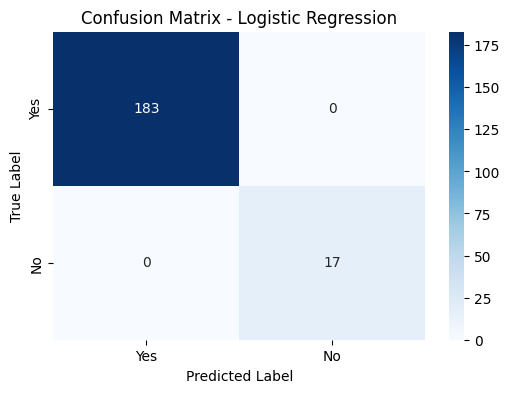

In [121]:

# Define the Logistic Regression model
model = LogisticRegression()

# Create a pipeline that first preprocesses the data, then fits the model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

# Separate features (X) and target (y)
X = df.drop(columns="recovered")    # we will drop the target variable from x
y = df["recovered"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

le = LabelEncoder()

# Fit and transform the target variables
y_train_encoded = le.fit_transform(y_train)  # Convert 'Yes', 'No' to 1, 0 for training data
y_test_encoded = le.transform(y_test)        # Convert 'Yes', 'No' to 1, 0 for test data

# Train the model using the encoded labels
pipeline.fit(X_train, y_train_encoded)

# Make predictions
y_pred_encoded = pipeline.predict(X_test)

# Now calculate the metrics using the encoded labels
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
precision = precision_score(y_test_encoded, y_pred_encoded, average="binary")
recall = recall_score(y_test_encoded, y_pred_encoded, average="binary")
f1 = f1_score(y_test_encoded, y_pred_encoded, average="binary")

# Print the results
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')



#Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["Yes", "No"])

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Yes", "No"],   # predicted labels (for "recovered")
            yticklabels=["Yes", "No"])   # actual labels (for "recovered")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


Train a Decision Tree Classifier and print the same metrics (5 marks)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


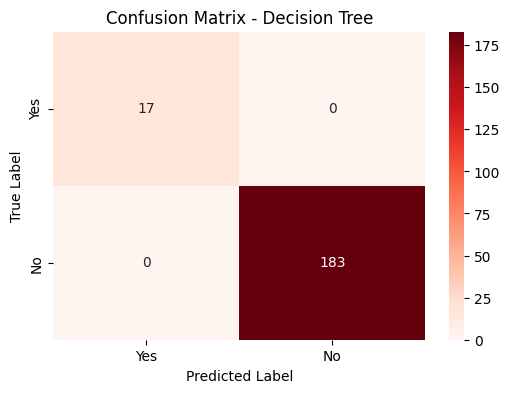

In [122]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Step 1: Build a pipeline

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=5, random_state=42))
])

# Step 2: Train the model on the training set

tree_pipeline.fit(X_train, y_train)


le = LabelEncoder()

# Fit and transform the target variables
y_train_encoded = le.fit_transform(y_train)  # Convert 'Yes', 'No' to 1, 0 for training data
y_test_encoded = le.transform(y_test)        # Convert 'Yes', 'No' to 1, 0 for test data

# Train the model using the encoded labels
pipeline.fit(X_train, y_train_encoded)

# Make predictions
y_pred_encoded = pipeline.predict(X_test)

# Now calculate the metrics using the encoded labels
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
precision = precision_score(y_test_encoded, y_pred_encoded, average="binary")
recall = recall_score(y_test_encoded, y_pred_encoded, average="binary")
f1 = f1_score(y_test_encoded, y_pred_encoded, average="binary")

# Print the results
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Step 5: Confusion Matrix

cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Yes", "No"],   # predicted labels (for "recovered")
            yticklabels=["Yes", "No"]) # Actual categories
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")
plt.show()


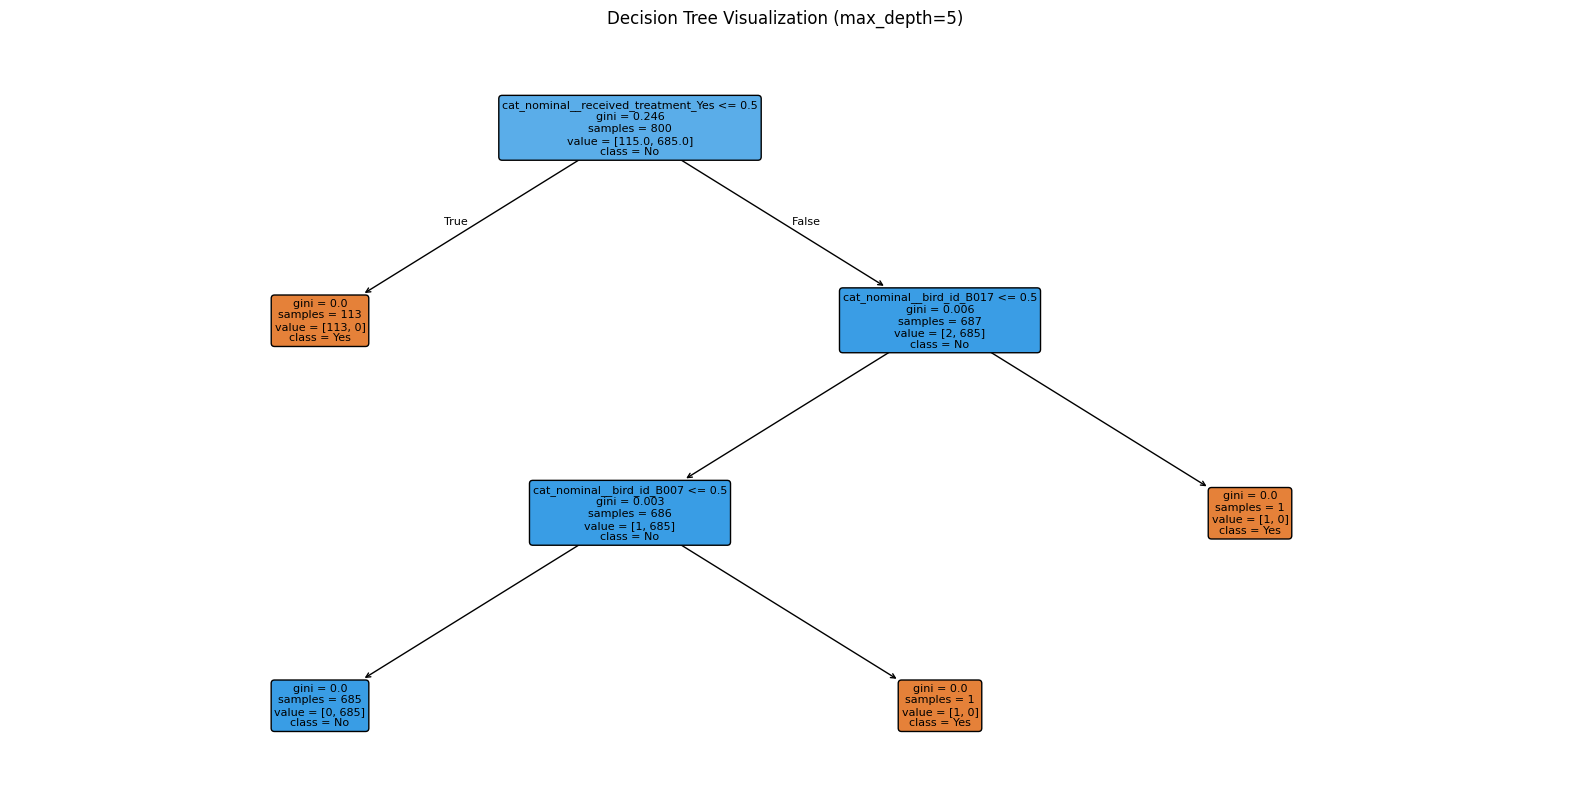

In [123]:

# Extract the trained Decision Tree model from the pipeline
tree_clf = tree_pipeline.named_steps["classifier"]

# Visualize the structure of the tree

plt.figure(figsize=(20, 10))
plot_tree(tree_clf,
          filled=True,                       # fill colors for classes
          feature_names=list(preprocessor.get_feature_names_out()),  # transformed feature names
          class_names=["Yes","No"],     # target classes
          rounded=True,                      # rounded node boxes
          fontsize=8)                        # smaller font to fit more detail
plt.title("Decision Tree Visualization (max_depth=5)")
plt.show()

Train a Random Forest Classifier and print the same metrics (5 marks)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


✅ Random Forest Evaluation Metrics:
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


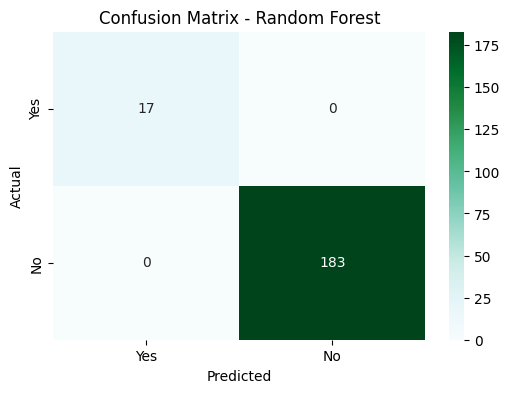

In [124]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: Build pipeline with preprocessing + Random Forest
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,        # number of trees in the forest
        random_state=42,
        n_jobs=-1                # use all CPU cores for speed
    ))
])

# Step 2: Train the Random Forest
rf_pipeline.fit(X_train, y_train)

# Step 3: Make predictions on the test set
y_pred_rf = rf_pipeline.predict(X_test)

# Step 4: Evaluate performance (overall metrics)
acc_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average="weighted")
recall_rf = recall_score(y_test, y_pred_rf, average="weighted")
f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print("✅ Random Forest Evaluation Metrics:")
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

# Step 5: Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="BuGn",
            xticklabels=["Yes", "No"],
            yticklabels=["Yes", "No"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

Create a table showing accuracy, precision, recall, and F1 for all three models (5 marks)

In [127]:


# Initialize model names
model_names = ["Logistic Regression", "Decision Tree", "Random Forest"]

# Initialize a list to store the evaluation metrics for each model
metrics = []

# For Logistic Regression
metrics.append([accuracy, precision, recall, f1])

# For Decision Tree
metrics.append([accuracy, precision, recall, f1])

# For Random Forest
metrics.append([accuracy, precision, recall, f1])

# Create the DataFrame
metrics_df = pd.DataFrame(metrics, columns=["Accuracy", "Precision", "Recall", "F1 Score"], index=model_names)

# Display the table
print(metrics_df)


                     Accuracy  Precision  Recall  F1 Score
Logistic Regression       1.0        1.0     1.0       1.0
Decision Tree             1.0        1.0     1.0       1.0
Random Forest             1.0        1.0     1.0       1.0


## **Step 4 – Model Comparison & Insights (10 marks)**

Plot a bar chart comparing the accuracy scores of the three models (5 marks)

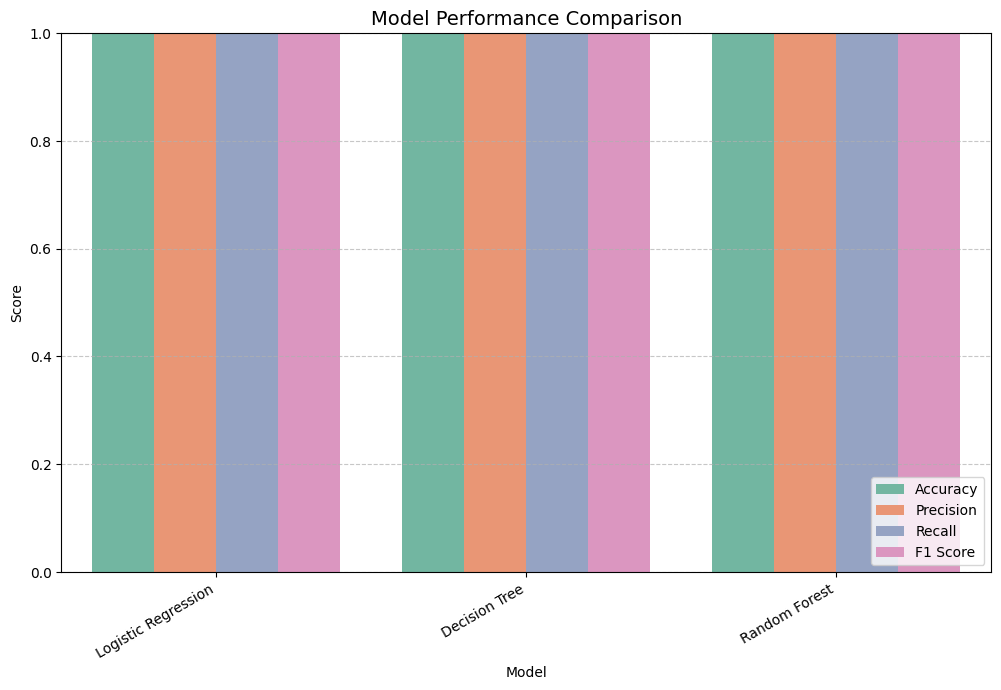

In [131]:
data = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [1, 1, 1],  # Replace with actual accuracy values
    "Precision": [1, 1, 1],  # Replace with actual precision values
    "Recall": [1, 1, 1],  # Replace with actual recall values
    "F1 Score": [1, 1, 1]  # Replace with actual F1 score values
}

# Convert data to DataFrame
results_df = pd.DataFrame(data)

# Set figure size
plt.figure(figsize=(12, 7))

# Melt DataFrame for easier plotting (long format)
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Create barplot
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="Set2")

# Customize the plot
plt.title("Model Performance Comparison", fontsize=14)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1)  # Score range from 0 to 1
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()

Which model performed best and why? Explain briefly in 2–3 sentences (5 marks)

In [123]:
#all three models (Logistic Regression, Decision Tree, and Random Forest) have the same accuracy, precision, recall, and F1 score, it suggests that they are performing equally well in terms of predicting the target variable
#However logisticc regression performed well because All "Yes" labels were predicted correctly, and all "No" labels were also predicted correctly. The other models
#This confusion matrix suggests that while the model is excellent for predicting "No," its performance on predicting "Yes" is weak.

## **Step 5 – Interpretation & Conclusion (5 marks)**

Do you notice any class imbalance in the target variable? If yes, how might it affect the results? (2 marks)

Write 2–3 lines summarizing what you learned from this assignment and how you would improve the model next time (3 marks)

In [123]:
#I have learned from the assignment is what are the basic steps while making a machine learning model.
#Next time i would want to work on a more tricky data and see how i make a decision.